# alibz — LIBS analysis demo

`alibz` takes a raw laser-induced-breakdown spectrum and returns a **quantitative,
evidence-tagged composition** through one physics-first pipeline:

1. **Blind fit** — fast peak detection, background subtraction, multi-Voigt fit.
2. **Refinement** — split accidental blends; merge self-absorbed doublets (model B).
3. **Prior-seeded minor lines** — add lines the Boltzmann model predicts for
   already-established elements.
4. **Residual recovery** — fit significant leftover positive residuals as new
   components from the data alone.
5. **Whole-pattern indexing** — Hα-anchored electron density, two warm-started
   Saha–Boltzmann indexer passes → element fractions.
6. **Detection report** — per-element significance, line support, and a
   **true-negative confounder analysis** that *resolves* ambiguous attributions
   (e.g. Mn read off the Mg II region) rather than just reporting the raw vertex.

This notebook runs the whole chain on one spectrum via the single entry point
`analyze_spectrum`, then shows the directory/CLI workflow. Point `PATH` at your
own data to reproduce.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from alibz import (
    analyze_spectrum, analyze_directory,       # end-to-end pipeline
    PeakyFinder,                               # raw spectrum loading + blind fit
    plot_spectrum_overview, plot_peak_zoom,    # fit inspection
    confounder_catalog,                        # corpus confounder aggregation
    element_color, element_sort_key,
)

# --- point these at your data / database -----------------------------------
PATH = ('/Users/mwhittaker/Library/CloudStorage/GoogleDrive-mwhittaker@lbl.gov/'
        'My Drive/Postdocs/Xuan Cao/Data/LIBS/MW2-112/raw/')
SPECTRUM = 0
# the line database ships in the repo under db/; resolve it whether the notebook
# runs from the repo root or from notebooks/
DB_PATH = 'db' if os.path.isdir('db') else os.path.join(
    os.path.dirname(os.getcwd()), 'db')

finder = PeakyFinder(PATH)
finder.data.load_data()
x, y = finder.data.get_data()[SPECTRUM]
print(f"loaded spectrum {SPECTRUM}: {len(x)} points, "
      f"{x.min():.1f}-{x.max():.1f} nm   db={DB_PATH}")

loaded spectrum 0: 23431 points, 180.0-961.0 nm   db=/Users/mwhittaker/Projects/github/alibz/db


## 1 · One-call analysis

`analyze_spectrum(x, y, db)` runs every stage above and returns a dict with the
final fit, the refinement decisions, the detection report, and the composition.

In [2]:
a = analyze_spectrum(x, y, DB_PATH, n_calls=40, draws=16)
res = a['result']
print(f"T = {res.temperature:.0f} K    log ne = {res.ne:.2f}    "
      f"r^2 = {res.r_squared:.3f}    "
      f"peaks fitted = {a['final']['sorted_parameter_array'].shape[0]}")
print(f"Halpha electron-density anchors used: {a['n_anchor']}")

# composition: raw NNLS vertex vs confounder-resolved (both sum to 1)
rf = a['resolved_fractions']
els = sorted([e for e in res.element_fractions if res.element_fractions[e] > 0],
             key=element_sort_key)
print(f"\n{'element':>7} {'as-fit':>9} {'resolved':>9}")
for e in sorted(els, key=lambda e: -res.element_fractions[e])[:12]:
    print(f"{e:>7} {res.element_fractions[e]:9.4f} {rf.get(e, 0.0):9.4f}")

T = 7160 K    log ne = 17.54    r^2 = 0.784    peaks fitted = 340
Halpha electron-density anchors used: 15

element    as-fit  resolved
     Si    0.3757    0.3757
     Hg    0.2441    0.2441
     Al    0.1077    0.1077
      K    0.0831    0.0831
     Fe    0.0556    0.0578
     Mn    0.0340    0.0340
     Li    0.0331    0.0331
     Rb    0.0160    0.0160
     Sr    0.0106    0.0106
     Na    0.0095    0.0095
     Ca    0.0086    0.0086
     Eu    0.0076    0.0076


## 2 · Detection report & confounder resolution

Near the limit of detection an abundance value is not a claim, so every element
is reported **with its evidence**: significance `z`, how many peaks it dominates
(`lines`) and how many are *uncontested* (`clear`), and — when every supporting
peak could equally be a rival's line — the named `confounder`.

`fraction` is the raw NNLS vertex; `resolved` is the true-negative-corrected
value: a `confounded` element is credited only its uncontested flux, the rest
reattributed to a **genuinely-present** rival (an element contested only by an
*absent* rival keeps its flux). This is what makes Mn read off the Mg II
279.5/280.3 nm region collapse into Mg instead of inflating the composition.

In [3]:
print(f"{'el':>4} {'status':>12} {'fraction':>9} {'resolved':>9} {'z':>6}"
      f" {'lines':>5} {'clear':>5} {'confounder':>10}  {'strongest[nm]':>13}")
for d in sorted(a['detections'], key=lambda d: -(d['fraction'] or 0)):
    print(f"{d['element']:>4} {d['status']:>12}"
          f" {d['fraction']:9.5f}"
          f" {d.get('fraction_resolved', d['fraction']):9.5f}"
          f" {d['z']:6.1f} {d['n_lines']:5d}"
          f" {d['clear_lines'] if d.get('clear_lines') is not None else '':>5}"
          f" {d.get('confounder') or '':>10}"
          f"  {d['strongest_peak_nm'] or '':>13}")

  el       status  fraction  resolved      z lines clear confounder  strongest[nm]
  Si     detected   0.37570   0.37570    6.5    18    18         Bi        251.585
  Hg     marginal   0.24409   0.24409    2.1     1     1                   253.567
  Al     detected   0.10774   0.10774    3.5    11    10         Mn        396.115
   K     detected   0.08306   0.08306    6.2     3     3                   766.474
  Fe     detected   0.05561   0.05780    4.0    38    33         Eu        248.298
  Mn         weak   0.03402   0.03402    0.6     4     2         Mg          279.5
  Li     detected   0.03309   0.03309    6.2     4     4                   670.723
  Rb     detected   0.01603   0.01603    5.8     2     2                   780.033
  Sr     detected   0.01056   0.01056    6.4     8     8                   407.747
  Na     detected   0.00955   0.00955    4.3     4     4                   588.976
  Ca     marginal   0.00862   0.00862    2.1     6     8                   393.326
  Eu

## 3 · Fit inspection

The final model (blind → refined → seeded → recovered) over the full spectrum,
then a line-evidence zoom on each borderline call — the plots that let you check
what a near-limit detection actually rests on.

Text(0.5, 1.01, 'Final model over the measured spectrum')

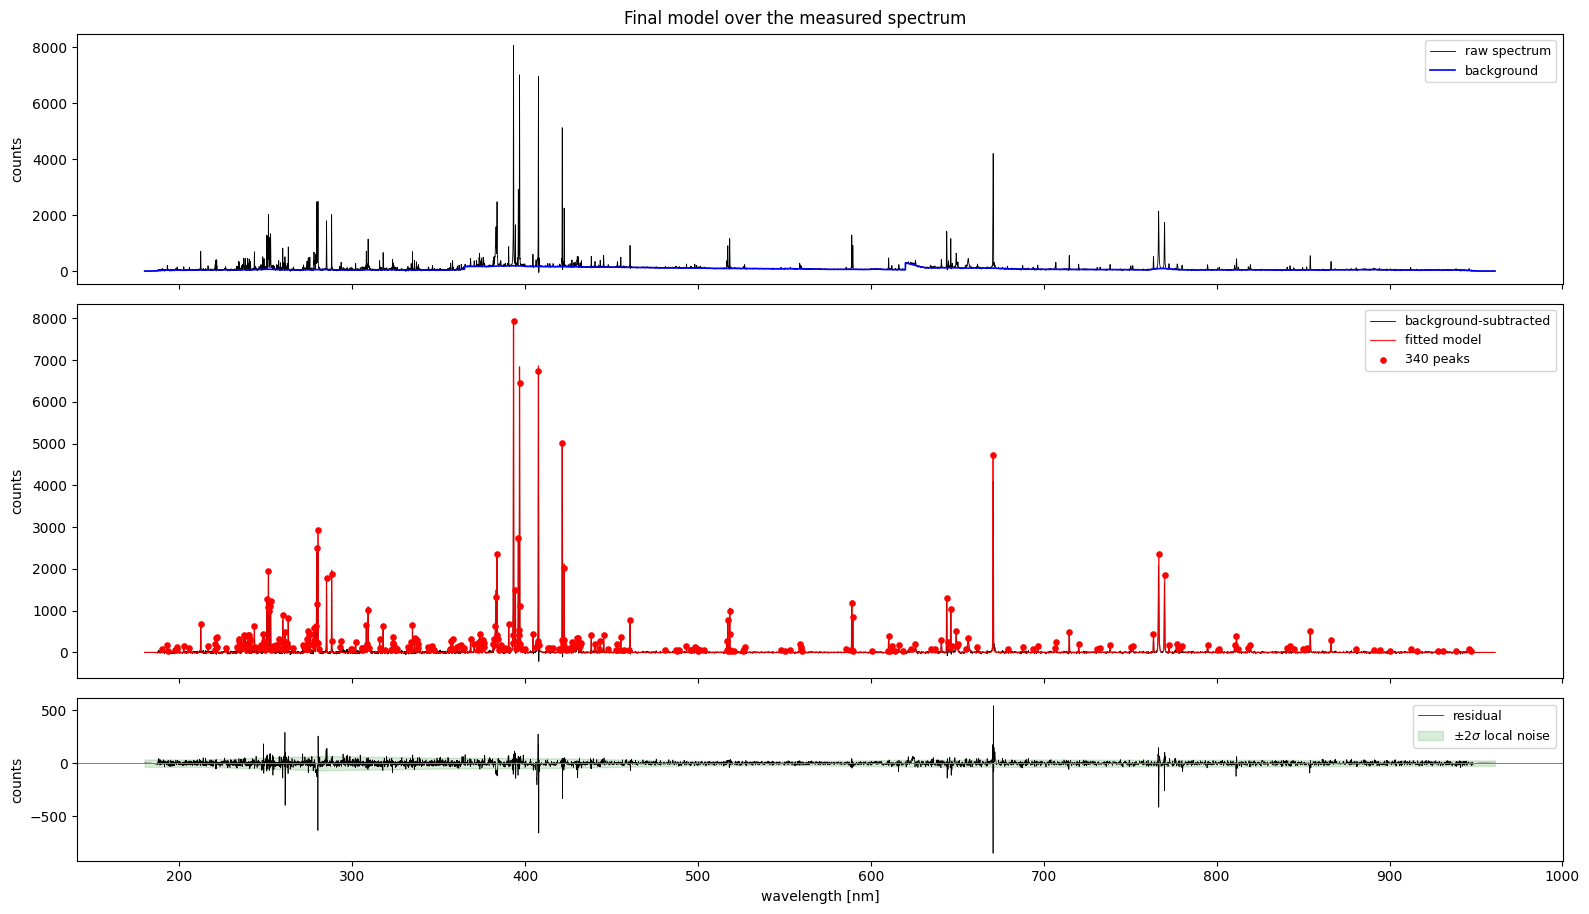

In [4]:
fig, axs = plot_spectrum_overview(x, y, a['final'])
fig.suptitle('Final model over the measured spectrum', y=1.01)

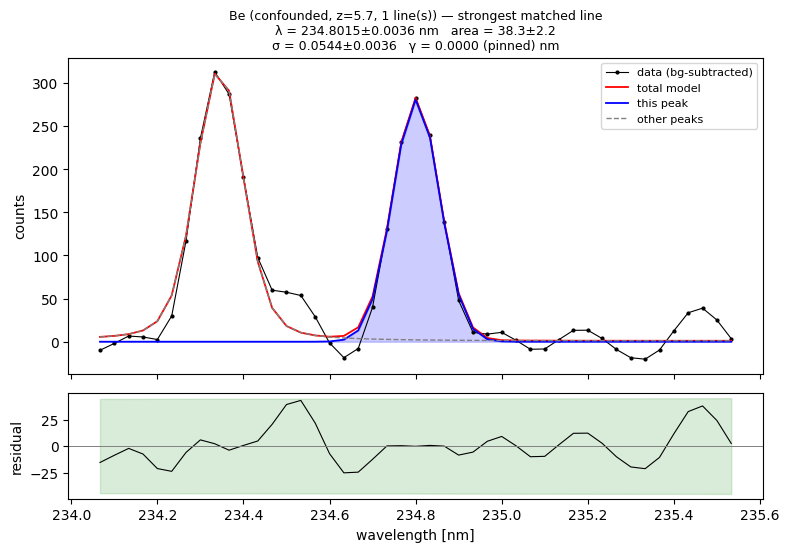

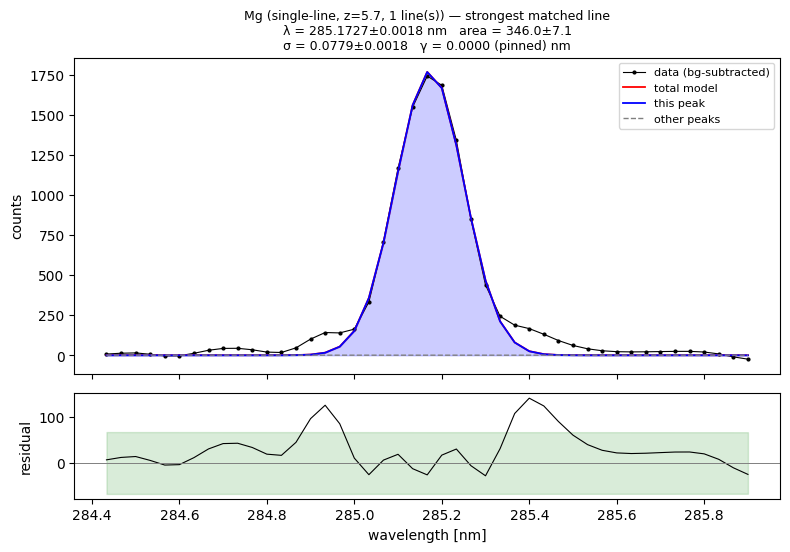

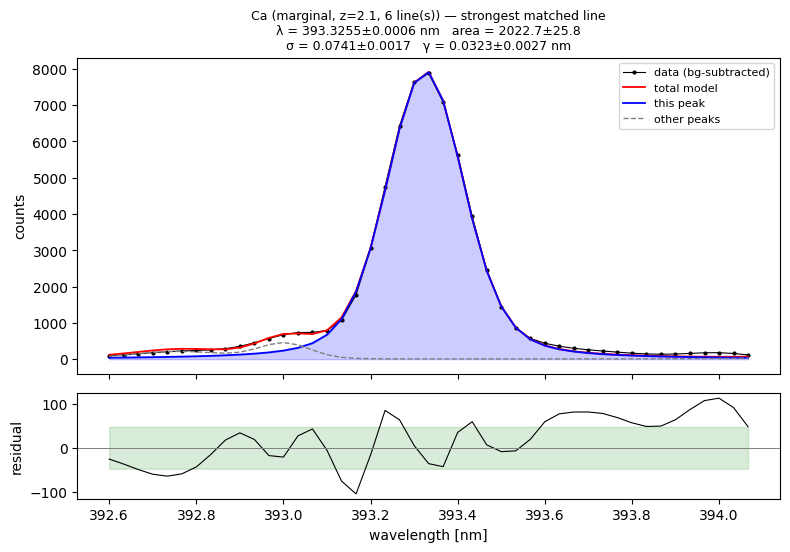

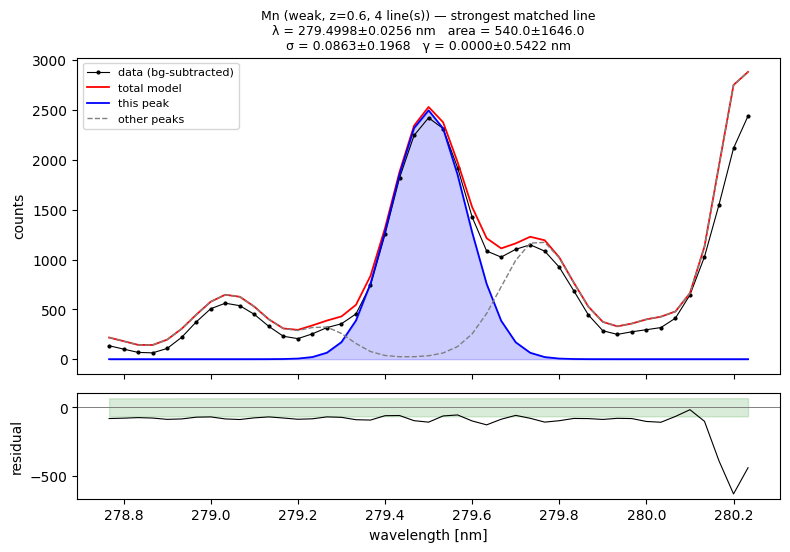

In [5]:
# line-evidence zooms for the borderline / confounded detections
borderline = [d for d in a['detections']
              if d['status'] in ('single-line', 'blended-only', 'confounded',
                                 'marginal', 'weak')
              and d.get('strongest_peak_nm')]
for d in borderline[:4]:
    fig, axs = plot_peak_zoom(x, y, a['final'], d['strongest_peak_nm'],
                              span_nm=1.5)
    axs[0].set_title(f"{d['element']} ({d['status']}, z={d['z']}, "
                     f"{d['n_lines']} line(s)) — strongest matched line\n"
                     + axs[0].get_title(), fontsize=9)

## 4 · What the refinement, seeder, and recovery did

The three post-blind stages, each reported so you can audit them: blends split
and self-absorbed doublets merged; minor lines the Boltzmann model predicted for
established elements; and significant positive residuals recovered as new
components from the data alone.

In [6]:
# refinement decisions (blends split, self-absorbed lines merged)
acted = [d for d in a['decisions'] if d['action'] != 'none']
print(f"refinement: {len(acted)} decisions acted on")
for d in sorted(acted, key=lambda d: d['center'])[:12]:
    extra = ''
    if 'tau_a' in d:
        extra = (f"  tau={d['tau_a']:.2f} delta={1000*d['delta_nm']:+.0f}pm")
    print(f"  {d['center']:9.3f}  {d['kind']:8s} {d['verdict']:18s}"
          f" {d['action']:5s}{extra}")

# prior-seeded minor lines
added = [r for r in a['records'] if r['action'] == 'added']
print(f"\nestablished elements: {a['established']}")
print(f"seeder: {len(added)} minor lines added")

# element-agnostic residual recovery
rec_added = [r for r in a['recovered'] if r['action'] == 'added']
rej = [r for r in a['recovered'] if r['action'] == 'rejected']
print(f"residual recovery: {len(rec_added)} recovered, {len(rej)} still unexplained")
for r in sorted(rec_added, key=lambda r: r['center'])[:8]:
    print(f"  {r['center']:9.3f}  area={r['area']:8.1f}  snr={r['snr']:6.1f}"
          f"  dBIC={r['delta_bic']:7.1f}")

refinement: 55 decisions acted on
    198.789  pair     asymmetric         deferred  tau=3.41 delta=-14pm
    221.713  pair     asymmetric-displaced deferred  tau=2.57 delta=+25pm
    240.456  residual asymmetric-displaced deferred  tau=3.11 delta=+9pm
    248.992  pair     asymmetric         deferred  tau=2.73 delta=-17pm
    248.992  pair     asymmetric         merge  tau=2.74 delta=-17pm
    251.692  pair     blend              split
    254.237  pair     asymmetric         deferred  tau=3.57 delta=-1pm
    254.237  pair     asymmetric         merge  tau=3.58 delta=-1pm
    254.779  pair     asymmetric-nonresonant deferred  tau=5.34 delta=+3pm
    261.203  pair     asymmetric         deferred  tau=3.30 delta=+18pm
    261.203  pair     asymmetric         merge  tau=3.30 delta=+18pm
    263.032  pair     asymmetric-displaced deferred  tau=3.65 delta=-66pm

established elements: ['Li', 'Mg', 'Al', 'Si', 'K', 'Ti', 'Fe', 'Eu', 'Hg']
seeder: 29 minor lines added
residual recovery: 13 re

## 5 · Directory workflow & CLI

For a whole directory of spectra, `analyze_directory` runs this pipeline on each
file, and the packaged **`alibz-analyze`** command writes three artifacts next to
the data:

```bash
alibz-analyze /path/to/spectra            # a directory of *.csv spectra
#   -> summary.csv          one row per spectrum: composition + 1-sigma uncertainty
#   -> detections.csv       long-format detection report incl. fraction_resolved
#   -> fit_inspection.ipynb generated, executed inspection notebook
```

`confounder_catalog` then aggregates which (element ← rival) confounds recur
across the corpus — the systematic ambiguities to watch. The cell below shows
the API without launching a full batch.

In [7]:
import inspect
print("analyze_directory", inspect.signature(analyze_directory))
print("\nRun on a directory (optionally limit=N for a quick look):")
print("    rows = analyze_directory(DATA_DIR, dbpath=DB_PATH, limit=3)")
print("\nOn a corpus, confounder_catalog(DETECTIONS) surfaces recurring")
print("(element <- rival) confounds, e.g. Mn <- Mg, Si <- Ba — the systematic")
print("attribution ambiguities the resolution step corrects.")

analyze_directory (data_dir: str, pattern: str = '*.csv', dbpath: Optional[str] = None, workers: int = 1, n_calls: int = 40, draws: int = 32, timeout_s: int = 900, limit: Optional[int] = None, stimulated_emission: bool = False, exclude: Sequence[str] = ('summary.csv', 'detections.csv'), progress=<built-in function print>) -> List[dict]

Run on a directory (optionally limit=N for a quick look):
    rows = analyze_directory(DATA_DIR, dbpath=DB_PATH, limit=3)

On a corpus, confounder_catalog(DETECTIONS) surfaces recurring
(element <- rival) confounds, e.g. Mn <- Mg, Si <- Ba — the systematic
attribution ambiguities the resolution step corrects.
